# Homework 2: Creating a regression model for predicting the car fuel efficiency (column 'fuel_efficiency_mpg')

In [162]:
import pandas as pd
import numpy as np

In [163]:
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'

In [164]:
!wget $data 

--2026-10-04 17:05:13--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv.4’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.1s    

2026-10-04 17:05:13 (5.84 MB/s) - ‘car_fuel_efficiency_2026.csv.4’ saved [635180/635180]



In [165]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')

In [166]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


# Columns Used:'engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg'

In [167]:
features = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year",
]
target = "fuel_efficiency_mpg"

In [168]:
df = df[features + [target]].copy()
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


In [169]:
df.dtypes

engine_displacement      int64
horsepower             float64
vehicle_weight           int64
model_year               int64
fuel_efficiency_mpg    float64
dtype: object

## Exploratory data analysis

In [170]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

engine_displacement
[2180 2390 2320 2130 2580]
127

horsepower
[243. 272. 267. 258. 304.]
153

vehicle_weight
[3870 4210 4240 4490 4510]
176

model_year
[2006 2008 1996 1989 1994]
50

fuel_efficiency_mpg
[31.9 31.3 27.5 28.5 31. ]
188



# Distribution of fuel_efficiency_mpg

In [171]:
import matplotlib.pyplot as plt
import seaborn as sns
# Forces plots to be created inline, although some Jupyter environment do this by default.
%matplotlib inline 

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

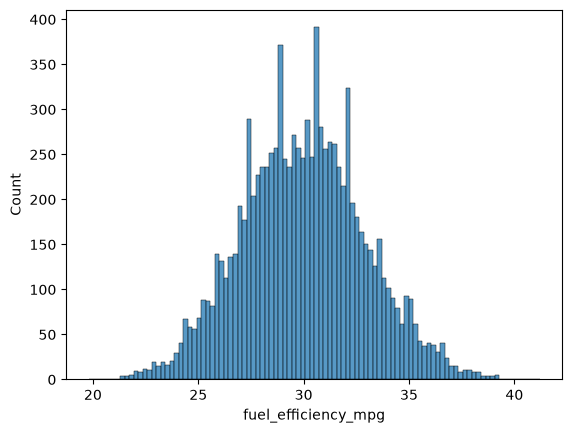

In [172]:
sns.histplot(df.fuel_efficiency_mpg, bins=100)

### [Question 1]
- There's one column with missing values. What is it?

In [173]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

### [Question 2]
- What's the median (50% percentile) for variable 'horsepower'?

In [174]:
df["horsepower"].median()

np.float64(254.0)

In [175]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test # leave the remainder in the training dataset

In [176]:
n

10000

In [177]:
n_val, n_test, n_train

(2000, 2000, 6000)

In [178]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year
6252,1900,239.0,3790,2015
4684,2000,224.0,4380,1992
1731,2330,286.0,4090,2022
4742,2300,NaN,4150,1997
4521,2340,269.0,4400,2001


In [179]:
np.random.seed(42) # specifies the seed to it is reproducible
idx = np.arange(n) # Creates sequence of numbers
np.random.shuffle(idx) # Shuffles the sequence

In [180]:
# Data cut with the randomized sequence
df_train = df.iloc[idx[:n_train]].copy()
df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
df_test = df.iloc[idx[n_train + n_val:]].copy()
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
6252,1900,239.0,3790,2015,32.5
4684,2000,224.0,4380,1992,29.1
1731,2330,286.0,4090,2022,34.1
4742,2300,NaN,4150,1997,30.6
4521,2340,269.0,4400,2001,30.7


In [181]:
len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

In [182]:
y_train = df_train["fuel_efficiency_mpg"].values
y_val = df_val["fuel_efficiency_mpg"].values
y_test = df_test["fuel_efficiency_mpg"].values

In [183]:
del df_train["fuel_efficiency_mpg"]
del df_val["fuel_efficiency_mpg"]
del df_test["fuel_efficiency_mpg"]

### [Question 3]
- We need to deal with missing values for the column from Q1.
- We have two options: fill it with 0 or with the mean of this variable.
- Try both options. For each, train a linear regression model without regularization using the code from the lessons.
- For computing the mean, use the training only!
- Use the validation dataset to evaluate the models and compare the RMSE of each option.
- Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release.
- Which option gives better RMSE?

#### Fill Missing Values with 0

In [184]:
df_train_0 = df_train.fillna(0)
df_train_0.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [185]:
df_val_0 = df_val.fillna(0)
df_val_0.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [186]:
X_train_0 = df_train_0.values
X_val_0 = df_val_0.values

In [187]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [188]:
X_train_0 = df_train_0.values
X_val_0 = df_val_0.values

In [189]:
w0, w = train_linear_regression(X_train_0, y_train)

In [190]:
y_pred = w0 + X_val_0.dot(w)

In [191]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()

    return np.sqrt(mse)

In [192]:
score_0 = rmse(y_val, y_pred)
score_0.round(3)

np.float64(2.205)

#### Fill Missing Values with mean

In [193]:
mean_value = df_train["horsepower"].mean()
mean_value

np.float64(254.46338337605272)

In [194]:
df_train_mean = df_train.fillna(mean_value)
df_train_0.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [195]:
df_val_mean = df_val.fillna(mean_value)
df_val_mean.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [196]:
X_train_mean = df_train_mean.values
X_val_mean = df_val_mean.values

In [197]:
w0, w = train_linear_regression(X_train_mean, y_train)

In [198]:
y_pred = w0 + X_val_mean.dot(w)

In [199]:
score_mean = rmse(y_val, y_pred)
score_mean.round(3)

np.float64(2.202)

In [200]:
score_0.round(3) - score_mean.round(3)

np.float64(0.0030000000000001137)

Filling missing values with the mean produced a lower / better validation RMSE

### [Question 4]
- Now let's train a regularized linear regression.
- For this question, fill the NAs with 0.
- Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
- Use RMSE to evaluate the model on the validation dataset.
- Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.
- Which r gives the best RMSE?

If multiple options give the same best RMSE, select the smallest r.

In [211]:
df_train_0.head()

,engine_displacement,horsepower,vehicle_weight,model_year
6252,1900,239.0,3790,2015
4684,2000,224.0,4380,1992
1731,2330,286.0,4090,2022
4742,2300,0.0,4150,1997
4521,2340,269.0,4400,2001


In [212]:
df_val_0.iloc[20:25]

,engine_displacement,horsepower,vehicle_weight,model_year
8768,2340,0.0,4130,1983
4207,2230,254.0,4080,2006
3218,2310,240.0,4350,1976
1391,2090,250.0,3840,1996
3975,2540,302.0,4800,2013


In [213]:
X_train = df_train_0.values
X_val = df_val_0.values

In [214]:
def train_linear_regression_reg(X, y, r=0.001):
    # Add a column of 1s for the bias term (w0)
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    # Calculate the Gram matrix
    XTX = X.T.dot(X)
    
    # Add 'r' to the main diagonal. The larger 'r' is, the smaller the values in the inverse, giving us more control over the weights.
    XTX = XTX + r * np.eye(XTX.shape[0])

    # Compute the inverse and the final weights (now safe from multicollinearity)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    # Return bias (w0) and weights (w) separately
    return w_full[0], w_full[1:]

In [219]:
results = []
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    
    # Train the model using the current value of 'r' to get our bias (w0) and weights (w)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    
    # Generate price predictions on the validation set using the trained weights
    y_pred = w0 + X_val.dot(w)
    
    # Calculate the RMSE to see how accurate the model is with this specific 'r' value
    score = rmse(y_val, y_pred)
    
    results.append((r, w0, score))
results

[(0, np.float64(-153.88496188223104), np.float64(2.205293194751098)),
 (0.01, np.float64(-148.3092124404723), np.float64(2.205827616672006)),
 (0.1, np.float64(-111.83871039307081), np.float64(2.2241432777850636)),
 (1, np.float64(-32.331865964969374), np.float64(2.349228888392786)),
 (5, np.float64(-7.772852209978469), np.float64(2.409380166599679)),
 (10, np.float64(-3.987116416019025), np.float64(2.4194698654732387)),
 (100, np.float64(-0.4082196488463344), np.float64(2.4292021380162367))]

In [223]:
sorted_results = sorted(results, key=lambda x: x[2])
for r, w0, score in sorted_results:
    print(r, w0, score)

0 -153.88496188223104 2.205293194751098
0.01 -148.3092124404723 2.205827616672006
0.1 -111.83871039307081 2.2241432777850636
1 -32.331865964969374 2.349228888392786
5 -7.772852209978469 2.409380166599679
10 -3.987116416019025 2.4194698654732387
100 -0.4082196488463344 2.4292021380162367


The best validation RMSE was achieved with `r = 0`

### [Question 5]
- We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
- Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
- For each seed, do the train/validation/test split with 60%/20%/20% distribution.
- Fill the missing values with 0 and train a model without regularization.
- For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
- What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
- Round the result to 3 decimal digits (round(std, 3))

What's the value of std?

In [224]:
scores = []

for seed in range(10):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)

    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].copy()
    df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
    df_test = df.iloc[idx[n_train + n_val:]].copy()

    y_train = df_train[target].values
    y_val = df_val[target].values

    del df_train[target]
    del df_val[target]
    del df_test[target]

    df_train = df_train.fillna(0)
    df_val = df_val.fillna(0)

    X_train = df_train.values
    X_val = df_val.values

    w0, w = train_linear_regression(X_train, y_train)

    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)

    scores.append(score)

    print(seed, score)
scores

0 2.2392041430461465
1 2.2021128210838907
2 2.163419778753095
3 2.2043588768539144
4 2.2018800943312926
5 2.2457851509084974
6 2.269721207952404
7 2.190794599933433
8 2.2166112016864443
9 2.207036592817851


[np.float64(2.2392041430461465),
 np.float64(2.2021128210838907),
 np.float64(2.163419778753095),
 np.float64(2.2043588768539144),
 np.float64(2.2018800943312926),
 np.float64(2.2457851509084974),
 np.float64(2.269721207952404),
 np.float64(2.190794599933433),
 np.float64(2.2166112016864443),
 np.float64(2.207036592817851)]

In [225]:
std = np.std(scores)

round(std, 3)

np.float64(0.029)

### Question 6
- Split the dataset like previously, use seed 9.
- Combine train and validation datasets.
- Fill the missing values with 0 and train a model with r=0.001.
- What's the RMSE on the test dataset?

In [230]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)

idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]].copy()
df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
df_test = df.iloc[idx[n_train + n_val:]].copy()

df_train_full = pd.concat([df_train, df_val])

y_train_full = df_train_full[target].values
y_test = df_test[target].values

del df_train_full[target]
del df_test[target]

df_train_full = df_train_full.fillna(0)
df_test = df_test.fillna(0)

X_train_full = df_train_full.values
X_test = df_test.values

w0, w = train_linear_regression_reg(
    X_train_full,
    y_train_full,
    r=0.001
)

y_pred = w0 + X_test.dot(w)

score = rmse(y_test, y_pred)

score.round(3)

np.float64(2.236)

In [76]:
# Define a reusable function to process the dataframe, now including feature engineering
def prepare_X(df):
    
    # Create a copy of the dataframe to avoid accidentally modifying the original dataset
    df = df.copy()
    
    # Create a brand new feature ('age') by subtracting the car's manufacture year from 2017 
    # (2017 is used here because it is the year this specific dataset was collected)
    df['age'] = 2017 - df['year']
    
    # Combine the original 'base' list of features with the newly created 'age' feature
    features = base + ['age']
    
    # Select only the specific columns defined in the updated 'features' list
    df_num = df[features]
    
    # Replace any missing data (NaN) with 0 so the math doesn't break
    df_num = df_num.fillna(0)
    
    # Strip away the Pandas formatting to extract a raw 2D NumPy array
    X = df_num.values

    # Output the final, cleaned feature matrix
    return X

In [77]:
# Process the training dataframe using the updated function (which now adds the 'age' feature)
X_train = prepare_X(df_train)

# Train a new model using the updated training features and training answers
# This calculates a new bias (w0) and weights (w) that now account for the added 'age' column
w0, w = train_linear_regression(X_train, y_train)

# Process the unseen validation dataframe, ensuring it gets the exact same 'age' feature added
X_val = prepare_X(df_val)

# Use the newly trained weights and bias to predict prices for the validation features
y_pred = w0 + X_val.dot(w)

# Compare the predictions against the actual validation answers to calculate the error score
# This tells you if adding the 'age' feature actually improved the model's accuracy
rmse(y_val, y_pred)

np.float64(0.5172055461058327)

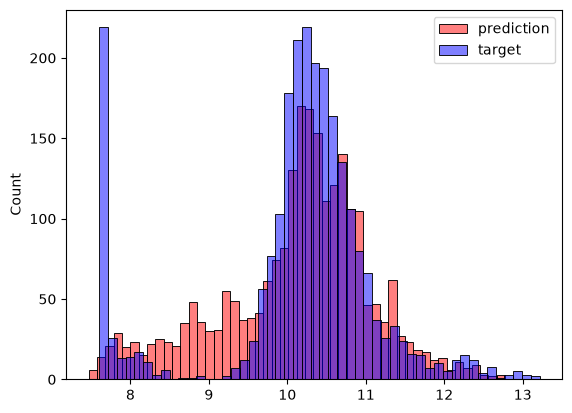

In [78]:
sns.histplot(y_pred, label='prediction', color='red', alpha=0.5, bins=50)
sns.histplot(y_val, label='target', color='blue',  alpha=0.5, bins=50) # Validation Set
plt.legend()

## 2.12 Categorical variables

In [79]:
# Define a list of categorical (text-based) column names that we want to use as features
categorical_columns = [
    'make', 'model', 'engine_fuel_type', 'driven_wheels', 'market_category',
    'vehicle_size', 'vehicle_style']

# Create an empty dictionary to store the most popular categories for each column
categorical = {}

# Loop through each categorical column name in the list above
for c in categorical_columns:
    # 1. df_train[c].value_counts(): Counts how many times each unique value appears in this column, sorted from most to least frequent
    # 2. .head(): Grabs only the top 5 most frequent values (since .head() defaults to 5 rows)
    # 3. .index: Extracts the actual text labels of those top 5 values (e.g., 'Chevrolet', 'Ford', 'Toyota')
    # 4. list(...): Converts those text labels into a standard Python list and saves it into the dictionary using the column name as the key
    categorical[c] = list(df_train[c].value_counts().head().index)

categorical

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'model': ['silverado_1500', 'tundra', 'f-150', 'sierra_1500', 'tacoma'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'hatchback',
  'luxury,performance'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

In [80]:
# Define the reusable function to process the dataframe and engineer features
def prepare_X(df):
    # Create a copy so we don't accidentally modify the original dataset
    df = df.copy()
    
    # Create the 'age' feature based on the year the data was collected
    df['age'] = 2017 - df['year']
    
    # Start the feature list with the original numerical columns plus 'age'
    features = base + ['age']

    # --- ONE-HOT ENCODING FOR NUMBER OF DOORS ---
    # Loop through the possible valid number of doors a car can have (2, 3, or 4)
    for v in [2, 3, 4]:
        # Create a new column (e.g., 'num_doors_2')
        # (df.number_of_doors == v) creates True/False. .astype(int) turns it into 1 or 0
        df['num_doors_%d' % v] = (df.number_of_doors == v).astype(int)
        
        # Add this new column name to our growing list of features
        features.append('num_doors_%d' % v)

    # --- ONE-HOT ENCODING FOR CATEGORICAL VARIABLES ---
    # Loop through the dictionary we created earlier (name = column, values = top 5 categories)
    for name, values in categorical.items():
        # Loop through each specific top category (e.g., 'Chevrolet', 'Ford')
        for value in values:
            # Create a new column combining the category and value (e.g., 'make_Chevrolet')
            # Check if the row matches this specific value, and convert True/False to 1/0
            df['%s_%s' % (name, value)] = (df[name] == value).astype(int)
            
            # Add this newly engineered binary column to our feature list
            features.append('%s_%s' % (name, value))

    # Filter the dataframe to keep ONLY the columns we've explicitly added to 'features'
    df_num = df[features]
    
    # Fill any remaining missing values (NaN) with 0 to prevent math errors
    df_num = df_num.fillna(0)
    
    # Convert the clean Pandas dataframe into a raw 2D NumPy array for the ML model
    X = df_num.values

    # Output the final feature matrix
    return X

In [81]:
# Process the training dataframe using the fully updated function 
# (which now includes 'age', plus one-hot encoding for doors and top categorical text features)
X_train = prepare_X(df_train)

# Train the linear regression model on this newly expanded, much wider feature matrix
# The model will now calculate a weight (w) for every single new category column we added
w0, w = train_linear_regression(X_train, y_train)

# Process the unseen validation dataframe, ensuring it gets the exact same one-hot encoded columns
X_val = prepare_X(df_val)

# Use the trained weights and bias to predict prices for the validation features
y_pred = w0 + X_val.dot(w)

# Compare predictions against the actual validation answers to calculate the error score
# This will show us how much the categorical feature engineering improved our model's accuracy
rmse(y_val, y_pred)

np.float64(113.57670443864478)

In [82]:
# Print the bias and weights to see WHY the RMSE is 266.
# Notice that w0 and several weights have exploded into the trillions/quadrillions (e.g., -3.06e+15).
# This is caused by linear dependence (multicollinearity) from one-hot encoding.
w0, w

(np.float64(-292975507188272.25),
 array([-1.94204667e-02, -8.44049639e+00,  4.18197946e-01, -7.24923387e-01,
        -1.43876150e-03, -7.43833334e-01,  8.71810032e+02,  8.46669570e+02,
         8.58349986e+02, -4.42390313e+00,  3.41491294e+00, -3.16297901e+00,
         8.58984632e+00, -1.15071526e+01, -1.96686350e+00, -1.07272250e+01,
        -4.82722874e+00, -2.93588658e+01, -6.00895660e+01, -9.18904890e+01,
        -8.66432254e+01, -9.59117190e+01, -8.73772648e+01, -9.92397920e+01,
         2.92975507e+14,  2.92975507e+14,  2.92975507e+14,  2.92975507e+14,
         2.47790122e+00,  1.90357987e+00, -4.57116994e+00, -4.32985422e-01,
        -2.87067662e+00, -2.92281644e+01, -3.80682704e+01, -3.58223622e+01,
        -1.44115660e-01, -2.62579827e-02,  1.75913981e-01,  3.65037816e-01,
        -2.90235596e-01]))

## 2.13 Regularization

In [83]:
# Create a small dummy feature matrix to simulate how real-world data is collected
# Notice that the second and third columns are meant to be identical, but the very last row has a tiny discrepancy
# The '5.00000001' represents "noise" (a tiny recording error or rounding artifact)
X = [
    [4, 4, 4],
    [3, 5, 5],
    [5, 1, 1],
    [5, 4, 4],
    [7, 5, 5],
    [4, 5, 5.00000001],
]

# Convert the standard Python list of lists into a 2D NumPy array 
# This is required so we can perform matrix math (like computing the Gram matrix XᵀX) on it
X = np.array(X)

# Output the array to visually inspect the data structure
X

array([[4.        , 4.        , 4.        ],
       [3.        , 5.        , 5.        ],
       [5.        , 1.        , 1.        ],
       [5.        , 4.        , 4.        ],
       [7.        , 5.        , 5.        ],
       [4.        , 5.        , 5.00000001]])

In [84]:
y= [1, 2, 3, 1, 2, 3]

In [85]:
XTX = X.T.dot(X) # Calculate the Gram matrix (XᵀX) by multiplying the transpose of X by X itself
XTX # (You will see that the 2nd and 3rd columns are almost identical, but not perfectly singular)

array([[140.        , 111.        , 111.00000004],
       [111.        , 108.        , 108.00000005],
       [111.00000004, 108.00000005, 108.0000001 ]])

In [86]:
# Compute the inverse of the Gram matrix
# Because of the tiny 5.00000001 "noise" we added, the matrix is technically invertible so this won't crash.
# However, the math becomes highly unstable, resulting in astronomically huge numbers.
XTX_inv = np.linalg.inv(XTX) # LinAlgError due to new NumPy version

LinAlgError: Singular matrix

In [89]:
# A simplified 3x3 matrix to demonstrate the math trap (columns 2 and 3 are almost identical).
XTX = [
    [1, 2, 2],
    [2, 1, 1.0000001],
    [2, 1.0000001, 1]
]

# Convert to a NumPy array to prepare for the regularization step.
XTX = np.array(XTX)

In [92]:
# 1. THE PROBLEM: Inverting a matrix with near-duplicate columns yields massive, unusable numbers.
np.linalg.inv(XTX)

array([[-3.33333356e-01,  3.33333339e-01,  3.33333339e-01],
       [ 3.33333339e-01, -5.00000008e+06,  4.99999991e+06],
       [ 3.33333339e-01,  4.99999991e+06, -5.00000008e+06]])

In [93]:
# 2. THE FIX: Regularization. Add a small number (0.01) to the diagonal using an identity matrix (np.eye).
# WHY THIS WORKS: Modifying the diagonal makes it mathematically less possible for one column to be an exact duplicate of another.
# This "regulates" or controls the weights so they don't grow too much.
XTX = XTX + 0.01 * np.eye(3)

In [94]:
# 3. THE VERIFICATION: Try the inverse again. The values in the inverse are now much smaller and under control.
np.linalg.inv(XTX)

array([[ -0.33668908,   0.33501399,   0.33501399],
       [  0.33501399,  49.91590897, -50.08509104],
       [  0.33501399, -50.08509104,  49.91590897]])

In [95]:
# 4. THE APPLICATION: Update the training function to include 'r' (the regularization parameter).
def train_linear_regression_reg(X, y, r=0.001):
    # Add a column of 1s for the bias term (w0)
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    # Calculate the Gram matrix
    XTX = X.T.dot(X)
    
    # Add 'r' to the main diagonal. The larger 'r' is, the smaller the values in the inverse, giving us more control over the weights.
    XTX = XTX + r * np.eye(XTX.shape[0])

    # Compute the inverse and the final weights (now safe from multicollinearity)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    # Return bias (w0) and weights (w) separately
    return w_full[0], w_full[1:]

In [96]:
# Prepare the training features (including the one-hot encoded categories).
X_train = prepare_X(df_train)

# Train using the NEW regularized function (with r=0.01) to prevent weights from exploding.
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

# Prepare the unseen validation features.
X_val = prepare_X(df_val)

# Predict validation prices using the stabilized weights.
y_pred = w0 + X_val.dot(w)

# Calculate RMSE. This regularized score (~0.46) doesn't just fix the broken model (41), 
# it actively beats the old baseline model before we added the categorical variables.
rmse(y_val, y_pred)

np.float64(0.4608208286405144)

## 2.14 Tuning the model

In [97]:
# Loop through a list of different regularization strengths (r) to find the best one.
# 0.0 is no regularization (will explode), while 10 is very strong regularization.
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:
    
    # Prepare the training features matrix 
    X_train = prepare_X(df_train)
    
    # Train the model using the current value of 'r' to get our bias (w0) and weights (w)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    # Prepare the unseen validation features matrix
    X_val = prepare_X(df_val)
    
    # Generate price predictions on the validation set using the trained weights
    y_pred = w0 + X_val.dot(w)
    
    # Calculate the RMSE to see how accurate the model is with this specific 'r' value
    score = rmse(y_val, y_pred)
    
    # Print the 'r' value, the resulting bias term (w0), and the final RMSE score.
    # Printing w0 is a great sanity check to watch how a higher 'r' stops the bias from exploding into the trillions!
    print(r, w0, score)

0.0 -292975507188272.25 113.57670443864478
1e-05 7.877078971316743 0.46081531619850896
0.0001 7.135017378203019 0.4608153644813666
0.001 7.131037736235349 0.46081585838303496
0.1 7.0002324072499675 0.46087365491260535
1 6.250747847380808 0.4615812838272154
10 4.729512585714189 0.47260987726669534


In [98]:
# Set the regularization parameter to 0.001.
# Why not 0.00001 (which had a mathematically lower score in the loop)? 
# A practical rule of thumb: if the difference in RMSE is less than 0.1% 
# (typically anything beyond the 3rd or 4th decimal place on a log scale), 
# the scores are "effectively tied." The variance is just random noise from how 
# the data was split. Here, the difference doesn't appear until the 6th decimal place.
# 
# When regularization scores tie, the rule is to always choose the larger 
# 'r' value. A larger 'r' applies stronger control over the weights, making the 
# model more robust and less likely to overfit or break on new, unseen data.
r = 0.001

# Process the training dataframe into our final feature matrix
X_train = prepare_X(df_train)

# Train the regularized linear regression model using the chosen 'r' value to get stable weights
w0, w = train_linear_regression_reg(X_train, y_train, r=r)

# Process the unseen validation dataframe using the exact same feature engineering steps
X_val = prepare_X(df_val)

# Generate price predictions for the validation set using our newly trained weights
y_pred = w0 + X_val.dot(w)

# Calculate the Root Mean Squared Error between the predictions and the actual validation answers
score = rmse(y_val, y_pred)

# Output the final RMSE score
score

np.float64(0.46081585838303496)

## 2.15 Using the model

In [99]:
# 1. FINAL MODEL TRAINING
# Combine the training and validation dataframes. Now that we've found our optimal 
# hyperparameter (r=0.001), we want to train the final model on as much data as possible.
df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)

In [100]:
# Process the combined dataframe into our feature matrix
X_full_train = prepare_X(df_full_train)
X_full_train

array([[148.,   4.,  33., ...,   1.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   0.,   1.],
       [148.,   4.,  37., ...,   0.,   0.,   1.],
       ...,
       [332.,   8.,  23., ...,   0.,   0.,   0.],
       [148.,   4.,  34., ...,   0.,   0.,   0.],
       [290.,   6.,  25., ...,   0.,   0.,   0.]], shape=(9532, 41))

In [101]:
# Combine the target values (y) to match the newly combined feature matrix
y_full_train = np.concatenate([y_train, y_val])

In [102]:
# Train the final regularized model on the full training dataset using our chosen r=0.001
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

In [103]:
# 2. FINAL MODEL EVALUATION
# Prepare the completely unseen test set using the same feature engineering pipeline
X_test = prepare_X(df_test)

In [104]:
# Generate predictions for the test set
y_pred = w0 + X_test.dot(w)

In [105]:
# Calculate final RMSE. This score represents our model's true performance on new data.
score = rmse(y_test, y_pred)
score

np.float64(0.4600753970741638)

In [106]:
# 3. SINGLE PREDICTION EXAMPLE
# Simulate a real-world scenario (like an API request) by extracting one car as a dictionary
car = df_test.iloc[20].to_dict()
car

{'make': 'toyota',
 'model': 'sienna',
 'year': 2015,
 'engine_fuel_type': 'regular_unleaded',
 'engine_hp': 266.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'front_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': nan,
 'vehicle_size': 'large',
 'vehicle_style': 'passenger_minivan',
 'highway_mpg': 25,
 'city_mpg': 18,
 'popularity': 2031}

In [107]:
# Convert the single car dictionary back into a DataFrame so our pipeline can process it
df_small = pd.DataFrame([car])
df_small

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,toyota,sienna,2015,regular_unleaded,266.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,passenger_minivan,25,18,2031


In [108]:
# Run the single-row DataFrame through our feature engineering function
X_small = prepare_X(df_small)

In [109]:
# Generate the prediction. Matrix operations always return an array, even for one row.
y_pred = w0 + X_small.dot(w)

In [110]:
# Extract the actual prediction number out of the 1-element array
y_pred = y_pred[0]
y_pred

np.float64(10.632492508372495)

In [111]:
# 4. INTERPRETING THE RESULT
# Convert the predicted log-price back into actual dollars using np.expm1 (the inverse of np.log1p)
np.expm1(y_pred)

np.float64(41459.33675535539)

In [112]:
# Compare our dollar prediction against the car's actual true price in dollars
np.expm1(y_test[20])

np.float64(35000.00000000001)

## 2.16 Next steps

* We included only 5 top features. What happens if we include 10?

Other projects

* Predict the price of a house - e.g. boston dataset
* https://archive.ics.uci.edu/ml/datasets.php?task=reg
* https://archive.ics.uci.edu/ml/datasets/Student+Performance

## 2.17 Summary

* EDA - looking at data, finding missing values
* Target variable distribution - long tail => bell shaped curve
* Validation framework: train/val/test split (helped us detect problems)
* Normal equation - not magic, but math
* Implemented it with numpy
* RMSE to validate our model
* Feature engineering: age, categorical features
* Regularization to fight numerical instability